# GNN_noKG — Baseline d'ablation
## Question de recherche
> *Dans quelle mesure l'intégration d'un graphe de connaissances hiérarchique (niveaux CECRL, unités, activités) améliore-t-elle la qualité des recommandations par rapport à un modèle n'utilisant que les interactions apprenant–activité ?*

**Protocole (inspiré KGAT, Wang et al. KDD 2019) :**
- Même architecture `ExponentialForgetting` que HIER-GNN
- **Sans** `HeteroGAT_KG` → embeddings items = `nn.Embedding` entraînables
- Même split LOO, mêmes métriques HR@10 / NDCG@10, même protocole 99 négatifs
- Les données (`g2_train.pt`, `g2_test.pt`, `g2_dynamic.pt`) sont produites par le notebook principal


In [1]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


## §0. Installation

In [2]:
!pip install torch torch_geometric scikit-learn pandas matplotlib -q
print('✓ Prêt')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.4 MB/s eta 0:00:00
✓ Prêt


## §1. Imports & Configuration

In [3]:
import os, copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch_geometric.data import HeteroData
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

# ── Même config que le notebook principal ─────────────────────────────────
CEFR_ORDER  = ['A1', 'A2', 'B1', 'B2', 'C1', 'C2']
CEFR_TO_IDX = {c: i for i, c in enumerate(CEFR_ORDER)}
MU          = 0.01697884130961766   # ← Optuna best (identique HIER-GNN)
K_RECENT    = 20
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED        = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'✓ Device : {DEVICE}')
print(f'✓ MU     : {MU}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Device : cpu
✓ MU     : 0.01697884130961766


## §2. Chargement des données

On charge les fichiers `.pt` produits par le notebook principal.

In [4]:
BASE = '/content/drive/MyDrive/pfe/'

print('[1/4] Chargement des graphes...')

g2_train   = torch.load(BASE + 'g2_train.pt',   map_location='cpu', weights_only=False)
g2_test    = torch.load(BASE + 'g2_test.pt',    map_location='cpu', weights_only=False)
g2_dynamic = torch.load(BASE + 'g2_dynamic.pt', map_location='cpu', weights_only=False)
g2_val     = torch.load(BASE + 'student_data_multi.pt', map_location='cpu', weights_only=False)

# ── Dimensions ──────────────────────────────────────────────────────────────
N_STU  = g2_train['student'].x.shape[0]
N_TASK = g2_train['task'].x.shape[0]
N_GRAM = g2_train['grammar'].x.shape[0]
N_VOC  = g2_train['vocabulary'].x.shape[0]
N_READ = g2_train['reading'].x.shape[0]

print(f'  Etudiants  : {N_STU:,}')
print(f'  Tasks      : {N_TASK}')
print(f'  Grammar    : {N_GRAM:,}')
print(f'  Vocabulary : {N_VOC:,}')
print(f'  Reading    : {N_READ:,}')

# ── Transfert GPU ────────────────────────────────────────────────────────────
g2_train_dev   = g2_train.to(DEVICE)
g2_test_dev    = g2_test.to(DEVICE)
g2_dynamic_dev = g2_dynamic.to(DEVICE)
g2_val_dev     = g2_val.to(DEVICE)

print('✓ Données chargées')


[1/4] Chargement des graphes...
  Etudiants  : 89,589
  Tasks      : 128
  Grammar    : 1,218
  Vocabulary : 7,459
  Reading    : 9,565
✓ Données chargées


## §3. Construction du split validation LOO

On reconstruit `g2_val_dev` à partir des interactions train, en appliquant le même protocole LOO que le notebook principal.

In [5]:
print('[2/4] Reconstruction split validation...')

# Interactions task brutes depuis g2_train
ei_task_raw = g2_train['student', 'attempted', 'task'].edge_index
ea_task_raw = g2_train['student', 'attempted', 'task'].edge_attr

stu_interactions = defaultdict(list)
for idx in range(ei_task_raw.shape[1]):
    s  = ei_task_raw[0, idx].item()
    a  = ei_task_raw[1, idx].item()
    tw = ea_task_raw[idx, 1].item()
    stu_interactions[s].append((tw, a, idx))

val_idx_list = []
for s, interactions in stu_interactions.items():
    interactions.sort(key=lambda x: x[0], reverse=True)
    if len(interactions) >= 3:
        val_idx_list.append(interactions[1][2])   # 2ème plus récent = val

val_idx = torch.tensor(val_idx_list, dtype=torch.long)

# Graphe val minimal (task uniquement, suffit pour HR/NDCG@10)
g2_val_nokg = HeteroData()
g2_val_nokg['student'].x    = g2_train['student'].x
g2_val_nokg['task'].x       = g2_train['task'].x
g2_val_nokg['grammar'].x    = g2_train['grammar'].x
g2_val_nokg['vocabulary'].x = g2_train['vocabulary'].x
g2_val_nokg['reading'].x    = g2_train['reading'].x
g2_val_nokg['student', 'attempted', 'task'].edge_index = ei_task_raw[:, val_idx]
g2_val_nokg['student', 'attempted', 'task'].edge_attr  = ea_task_raw[val_idx]

# Val maps : stu → liste de tâches validées
def build_val_maps_nokg(g2_val):
    val_map = {}
    et = ('student', 'attempted', 'task')
    if et not in g2_val.edge_types:
        return {'task': {}}
    ei = g2_val[et].edge_index
    m  = defaultdict(list)
    for s, a in zip(ei[0].tolist(), ei[1].tolist()):
        m[s].append(a)
    return {'task': dict(m)}

val_maps_nokg = build_val_maps_nokg(g2_val_nokg)
g2_val_nokg_dev = g2_val_nokg.to(DEVICE)

print(f'  Val students : {len(val_maps_nokg["task"]):,}')
print('✓ Split validation prêt')


[2/4] Reconstruction split validation...
  Val students : 23,764
✓ Split validation prêt


## §4. Architecture GNN_noKG

**Principe d'ablation :** on retire `HeteroGAT_KG` et on remplace les embeddings items enrichis par le KG par de simples `nn.Embedding` entraînables. Le bloc `ExponentialForgetting` est **identique** à HIER-GNN.

In [6]:
# ── ExponentialForgetting (copie exacte de HIER-GNN) ──────────────────────
class ExponentialForgetting(nn.Module):
    def __init__(self, out_dim=64, mu=MU, tw_min=0.1, stu_feat_dim=128):
        super().__init__()
        self.mu      = mu
        self.tw_min  = tw_min
        self.out_dim = out_dim

        self.student_proj = nn.Sequential(
            nn.Linear(stu_feat_dim, out_dim),
            nn.ReLU(),
            nn.LayerNorm(out_dim),
        )
        self.gate = nn.Sequential(
            nn.Linear(out_dim * 2, out_dim),
            nn.ReLU(),
            nn.Linear(out_dim, 1),
            nn.Sigmoid(),
        )
        self.proj = nn.Sequential(
            nn.Linear(out_dim, out_dim),
            nn.ReLU(),
        )
        self.type_weights = nn.ParameterDict({
            'task'      : nn.Parameter(torch.ones(1)),
            'grammar'   : nn.Parameter(torch.ones(1) * 0.7),
            'vocabulary': nn.Parameter(torch.ones(1) * 0.7),
            'reading'   : nn.Parameter(torch.ones(1) * 0.7),
        })
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, g2_dynamic, h_nodes_dict, N_stu):
        device    = next(self.parameters()).device
        stu_x     = g2_dynamic['student'].x.to(device)
        e_static  = self.student_proj(stu_x)

        e_dynamic = torch.zeros(N_stu, self.out_dim, device=device)
        n_inter   = torch.zeros(N_stu, device=device)

        edge_map = {
            'task'      : ('student', 'attempted',  'task'),
            'grammar'   : ('student', 'practiced',  'grammar'),
            'vocabulary': ('student', 'studied',    'vocabulary'),
            'reading'   : ('student', 'read',       'reading'),
        }
        for node_type, et in edge_map.items():
            if et not in g2_dynamic.edge_types:
                continue
            h_node = h_nodes_dict[node_type].to(device)
            ei     = g2_dynamic[et].edge_index
            ea     = g2_dynamic[et].edge_attr
            src    = ei[0]
            dst    = ei[1].clamp(max=h_node.shape[0] - 1)
            tw     = ea[:, 0].clamp(min=self.tw_min, max=1.0)
            w      = torch.sigmoid(self.type_weights[node_type])
            weighted = (tw * w).unsqueeze(1) * h_node[dst]
            e_dynamic.scatter_add_(0, src.unsqueeze(1).expand(-1, self.out_dim), weighted)
            n_inter.scatter_add_(0, src, torch.ones(src.shape[0], device=device))

        n_safe    = n_inter.clamp(min=1.0)
        e_dynamic = e_dynamic / n_safe.sqrt().unsqueeze(1)

        gate_input = torch.cat([e_static, e_dynamic], dim=-1)
        alpha      = self.gate(gate_input)
        e_stu      = alpha * e_dynamic + (1.0 - alpha) * e_static
        return self.norm(self.proj(e_stu))


# ── GNN_noKG : ablation sans HeteroGAT_KG ────────────────────────────────
class GNN_noKG(nn.Module):
    """
    Modèle d'ablation : ExponentialForgetting identique à HIER-GNN
    SANS HeteroGAT_KG — les embeddings items sont des nn.Embedding
    entraînables, non enrichis par le KG hiérarchique CECRL.
    """
    def __init__(self, n_tasks, n_gram, n_voc, n_read,
                 out_dim=64, mu=MU, tw_min=0.1):
        super().__init__()

        # Embeddings items entraînables (remplacent HeteroGAT_KG)
        self.item_emb = nn.ModuleDict({
            'task'      : nn.Embedding(n_tasks, out_dim),
            'grammar'   : nn.Embedding(n_gram,  out_dim),
            'vocabulary': nn.Embedding(n_voc,   out_dim),
            'reading'   : nn.Embedding(n_read,  out_dim),
        })
        for emb in self.item_emb.values():
            nn.init.xavier_normal_(emb.weight)

        # Bloc oubli identique HIER-GNN
        self.forgetting = ExponentialForgetting(out_dim=out_dim, mu=mu, tw_min=tw_min)

    def forward(self, g2_dynamic, N_stu):
        h_nodes   = {k: emb.weight for k, emb in self.item_emb.items()}
        e_student = self.forgetting(g2_dynamic, h_nodes, N_stu)
        return h_nodes, e_student


print('✓ ExponentialForgetting + GNN_noKG définis')


✓ ExponentialForgetting + GNN_noKG définis


## §5. Fonctions utilitaires (BPR loss, évaluation LOO)

In [7]:
EDGE_MAP = {
    'task'      : ('student', 'attempted',  'task'),
    'grammar'   : ('student', 'practiced',  'grammar'),
    'vocabulary': ('student', 'studied',    'vocabulary'),
    'reading'   : ('student', 'read',       'reading'),
}
NODE_SIZES = {
    'task': N_TASK, 'grammar': N_GRAM,
    'vocabulary': N_VOC, 'reading': N_READ,
}

def bpr_loss(e_stu, h_pos, h_neg, l2=1e-4):
    pos_s = (e_stu * h_pos).sum(-1)
    neg_s = (e_stu * h_neg).sum(-1)
    loss  = -F.logsigmoid(pos_s - neg_s).mean()
    loss += l2 * (e_stu.norm(2, dim=-1).mean() +
                  h_pos.norm(2, dim=-1).mean() +
                  h_neg.norm(2, dim=-1).mean())
    return loss

def uniformity_loss(z, t=2.0):
    z  = F.normalize(z, dim=-1)
    sq = torch.cdist(z, z).pow(2)
    return torch.log(torch.exp(-t * sq).mean() + 1e-8)

def evaluate_nokg(model, g2_dynamic, g2_train, val_maps,
                  N_stu, k=10, n_neg=99):
    """Évaluation LOO + 99 négatifs sur tous les types (task, grammar, vocab, reading)."""
    model.eval()
    with torch.no_grad():
        h_nodes, e_student = model(g2_dynamic, N_stu)

    std_diag  = e_student.std().item()
    all_ndcgs = []
    results   = {}

    for node_type, et_key in EDGE_MAP.items():
        val_map = val_maps.get(node_type, {})
        if not val_map:
            continue

        N_nodes  = NODE_SIZES[node_type]
        h_norm   = F.normalize(h_nodes[node_type], p=2, dim=-1)
        all_items= np.arange(N_nodes)
        hits, ndcgs = [], []

        for stu, acts in val_map.items():
            if not acts:
                continue
            pos_item = acts[-1]
            if pos_item >= N_nodes:
                continue

            neg_pool   = np.setdiff1d(all_items, [pos_item])
            neg_sample = np.random.choice(neg_pool, min(n_neg, len(neg_pool)), replace=False)
            candidates = torch.tensor([pos_item] + neg_sample.tolist(),
                                      dtype=torch.long, device=DEVICE)

            e_u    = F.normalize(e_student[stu].unsqueeze(0), p=2, dim=-1)
            scores = (e_u * h_norm[candidates]).sum(-1)
            ranked = torch.argsort(scores, descending=True).tolist()
            rank   = ranked.index(0) + 1

            hits.append(1 if rank <= k else 0)
            ndcgs.append(1 / np.log2(rank + 1) if rank <= k else 0.0)

        hr   = np.mean(hits)  if hits  else 0.0
        ndcg = np.mean(ndcgs) if ndcgs else 0.0
        results[node_type] = {'HR': hr, 'NDCG': ndcg, 'n': len(hits)}
        all_ndcgs.extend(ndcgs)

    ndcg_global = np.mean(all_ndcgs) if all_ndcgs else 0.0
    hr_task     = results.get('task', {}).get('HR', 0.0)
    return hr_task, ndcg_global, results, std_diag

print('✓ Fonctions utilitaires prêtes')


✓ Fonctions utilitaires prêtes


## §6. Entraînement GNN_noKG

Mêmes hyperparamètres que HIER-GNN (LR, batch size, patience, grad clip, uniformity loss).

In [ ]:
# ── Hyperparamètres (alignés HIER-GNN) ──────────────────────────────────
BATCH_SIZE  = 4096
LR          = 0.0018844973128841452
PATIENCE    = 10
EPOCHS      = 80
EVAL_EVERY  = 5
GRAD_CLIP   = 1.0
UNIF_W      = 0.06776612817421043
UNIF_SAMPLE = 1024
MULTI_W_GRAM = 0.5
MULTI_W_VOC  = 1.0
MULTI_W_READ = 0.5
OUT_DIM      = 64

os.makedirs('checkpoints_nokg', exist_ok=True)

# ── Instanciation ────────────────────────────────────────────────────────
model_nokg = GNN_noKG(
    n_tasks=N_TASK, n_gram=N_GRAM, n_voc=N_VOC, n_read=N_READ,
    out_dim=OUT_DIM, mu=MU
).to(DEVICE)

optimizer = torch.optim.Adam(model_nokg.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-6)

# ── Edges train ──────────────────────────────────────────────────────────
ei_tr_task = g2_train_dev['student', 'attempted', 'task'].edge_index
ei_tr_gram = g2_train_dev['student', 'practiced',  'grammar'].edge_index
ei_tr_voc  = g2_train_dev['student', 'studied',    'vocabulary'].edge_index
ei_tr_read = g2_train_dev['student', 'read',       'reading'].edge_index
n_task_edges = ei_tr_task.shape[1]

BS_GRAM = BATCH_SIZE // 4
BS_VOC  = BATCH_SIZE // 2
BS_READ = BATCH_SIZE // 4

best_ndcg, best_hr   = 0.0, 0.0
best_state, patience_cnt = None, 0
history = []

print(f'Entraînement GNN_noKG | device={DEVICE} | lr={LR} | batch={BATCH_SIZE}')
print('─'*60)

for epoch in range(EPOCHS):
    model_nokg.train()
    optimizer.zero_grad()

    h_nodes, e_student = model_nokg(g2_dynamic_dev, N_STU)

    # ── BPR loss task ─────────────────────────────────────────────────────
    idx_b = torch.randint(0, n_task_edges, (BATCH_SIZE,), device=DEVICE)
    src_b = ei_tr_task[0][idx_b]
    dst_b = ei_tr_task[1][idx_b].clamp(max=N_TASK - 1)
    neg_b = torch.randint(0, N_TASK, (BATCH_SIZE,), device=DEVICE)
    loss  = bpr_loss(e_student[src_b],
                     h_nodes['task'][dst_b],
                     h_nodes['task'][neg_b])

    # ── BPR loss grammar ─────────────────────────────────────────────────
    if ei_tr_gram.shape[1] > 0:
        idx_g = torch.randint(0, ei_tr_gram.shape[1], (BS_GRAM,), device=DEVICE)
        src_g = ei_tr_gram[0][idx_g]
        dst_g = ei_tr_gram[1][idx_g].clamp(max=N_GRAM - 1)
        neg_g = torch.randint(0, N_GRAM, (BS_GRAM,), device=DEVICE)
        loss  = loss + MULTI_W_GRAM * bpr_loss(
            e_student[src_g], h_nodes['grammar'][dst_g], h_nodes['grammar'][neg_g])

    # ── BPR loss vocabulary ───────────────────────────────────────────────
    if ei_tr_voc.shape[1] > 0:
        idx_v = torch.randint(0, ei_tr_voc.shape[1], (BS_VOC,), device=DEVICE)
        src_v = ei_tr_voc[0][idx_v]
        dst_v = ei_tr_voc[1][idx_v].clamp(max=N_VOC - 1)
        neg_v = torch.randint(0, N_VOC, (BS_VOC,), device=DEVICE)
        loss  = loss + MULTI_W_VOC * bpr_loss(
            e_student[src_v], h_nodes['vocabulary'][dst_v], h_nodes['vocabulary'][neg_v])

    # ── BPR loss reading ──────────────────────────────────────────────────
    if ei_tr_read.shape[1] > 0:
        idx_r = torch.randint(0, ei_tr_read.shape[1], (BS_READ,), device=DEVICE)
        src_r = ei_tr_read[0][idx_r]
        dst_r = ei_tr_read[1][idx_r].clamp(max=N_READ - 1)
        neg_r = torch.randint(0, N_READ, (BS_READ,), device=DEVICE)
        loss  = loss + MULTI_W_READ * bpr_loss(
            e_student[src_r], h_nodes['reading'][dst_r], h_nodes['reading'][neg_r])

    # ── Uniformity loss ───────────────────────────────────────────────────
    perm = torch.randperm(N_STU, device=DEVICE)[:UNIF_SAMPLE]
    loss = loss + UNIF_W * uniformity_loss(e_student[perm])

    # ── Régularisation mu ─────────────────────────────────────────────────
    loss = loss + MU * e_student.norm(2, dim=-1).mean()

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_nokg.parameters(), GRAD_CLIP)
    optimizer.step()

    # ── Évaluation ────────────────────────────────────────────────────────
    if (epoch + 1) % EVAL_EVERY == 0:
        hr_task, ndcg_global, res_per_type, std_diag = evaluate_nokg(
            model_nokg, g2_dynamic_dev, g2_train_dev,
            val_maps_nokg, N_STU, k=10)

        scheduler.step(ndcg_global)

        history.append({
            'epoch'      : epoch + 1,
            'loss'       : loss.item(),
            'HR@10_task' : hr_task,
            'NDCG_global': ndcg_global,
            'stu_std'    : std_diag,
            **{f'NDCG_{t}': v['NDCG'] for t, v in res_per_type.items()},
            **{f'HR_{t}'  : v['HR']   for t, v in res_per_type.items()},
        })

        tag = ''
        if ndcg_global > best_ndcg + 1e-4:
            best_hr      = hr_task
            best_ndcg    = ndcg_global
            best_state   = copy.deepcopy(model_nokg.state_dict())
            patience_cnt = 0
            torch.save(best_state, 'checkpoints_nokg/best_gnn_nokg.pt')
            tag = '✅'
        else:
            patience_cnt += 1

        lr_cur = optimizer.param_groups[0]['lr']
        print(f'  Epoch {epoch+1:3d} — NDCG={ndcg_global:.4f}  '
              f'std={std_diag:.4f}  lr={lr_cur:.1e} {tag}')

        if patience_cnt >= PATIENCE:
            print(f'  ⏹ Early stopping epoch {epoch+1}  '
                  f'(best NDCG_global={best_ndcg:.4f})')
            break

# ── Chargement meilleur état ──────────────────────────────────────────────
if best_state:
    model_nokg.load_state_dict(best_state)

model_nokg.eval()
with torch.no_grad():
    h_nodes_nokg, e_student_nokg = model_nokg(g2_dynamic_dev, N_STU)

print(f'\n✓ Entraînement terminé')
print(f'  best_val_HR@10_task  : {best_hr:.4f}')
print(f'  best_val_NDCG_global : {best_ndcg:.4f}')
std_final = e_student_nokg.std().item()
print(f'  Student emb std      : {std_final:.4f}',
      '✅' if std_final > 0.15 else '⚠ collapse → augmenter UNIF_W')


## §8. Évaluation finale (test set)

Même protocole que §9 du notebook principal : LOO + 99 négatifs, métriques globales.

In [16]:
# ═══════════════════════════════════════════════════════════════════════════
# §8. Évaluation finale — HR, NDCG, Precision, Recall, MRR
# ═══════════════════════════════════════════════════════════════════════════

print('[Évaluation finale GNN_noKG]')
np.random.seed(42)

EDGE_MAP_NOKG = {
    'task'      : ('student', 'attempted',  'task'),
    'grammar'   : ('student', 'practiced',  'grammar'),
    'vocabulary': ('student', 'studied',    'vocabulary'),
    'reading'   : ('student', 'read',       'reading'),
}

def compute_metrics_nokg(e_student, h_nodes, g2_test, g2_train,
                          node_sizes, n_neg=99, ks=[5, 10]):

    results = {k: {'hr':[], 'ndcg':[], 'precision':[], 'recall':[], 'mrr':[]}
               for k in ks}

    items_recommended = {k: set() for k in ks}
    total_items = 0
    n_eval      = 0

    ei_tr     = g2_train['student', 'attempted', 'task'].edge_index
    stu_count = torch.bincount(ei_tr[0],
                               minlength=e_student.shape[0]).cpu().numpy()

    with torch.no_grad():
        e_stu_np = F.normalize(e_student, p=2, dim=-1).cpu().numpy()

    for node_type, et_key in EDGE_MAP_NOKG.items():
        if et_key not in g2_test.edge_types:
            print(f'  ⚠ {node_type} absent de g2_test — ignoré')
            continue

        N_nodes      = node_sizes[node_type]
        total_items += N_nodes

        with torch.no_grad():
            h_np = F.normalize(h_nodes[node_type], p=2, dim=-1).cpu().numpy()

        ei_test = g2_test[et_key].edge_index
        stu_pos = defaultdict(list)
        for s, a in zip(ei_test[0].tolist(), ei_test[1].tolist()):
            if a < N_nodes:
                stu_pos[s].append(a)

        all_items = np.arange(N_nodes, dtype=np.int64)

        for stu, pos_items in stu_pos.items():
            if stu_count[stu] < 3:
                continue

            pos_item = pos_items[-1]

            neg_pool = np.setdiff1d(all_items,
                                    np.array(pos_items, dtype=np.int64))
            rng      = np.random.default_rng(stu + hash(node_type) % 10000)
            idx      = rng.choice(len(neg_pool),
                                  min(n_neg, len(neg_pool)), replace=False)
            cands    = np.concatenate([[pos_item], neg_pool[idx]])

            scores = h_np[cands] @ e_stu_np[stu]
            ranked = np.argsort(-scores)
            rank   = int(np.where(ranked == 0)[0][0]) + 1
            n_eval += 1

            for k in ks:
                hit = 1.0 if rank <= k else 0.0
                results[k]['hr'].append(hit)
                results[k]['ndcg'].append(
                    1.0 / np.log2(rank + 1) if rank <= k else 0.0)
                results[k]['precision'].append(hit / k)
                results[k]['recall'].append(hit)
                results[k]['mrr'].append(1.0 / rank if rank <= k else 0.0)
                items_recommended[k].update(cands[ranked[:k]].tolist())

    def avg(lst): return float(np.mean(lst)) if lst else 0.0

    out = {'n_total': n_eval // len(ks)}
    for k in ks:
        r = results[k]
        out[f'HR@{k}']        = avg(r['hr'])
        out[f'NDCG@{k}']      = avg(r['ndcg'])
        out[f'Precision@{k}'] = avg(r['precision'])
        out[f'Recall@{k}']    = avg(r['recall'])
        out[f'MRR@{k}']       = avg(r['mrr'])
        out[f'Coverage@{k}']  = (len(items_recommended[k]) / total_items
                                  if total_items > 0 else 0.0)
    return out


import time
t0 = time.time()
metrics_nokg = compute_metrics_nokg(
    e_student_nokg, h_nodes_nokg,
    g2_test_dev, g2_train_dev,
    NODE_SIZES, n_neg=99, ks=[5, 10]
)
print(f'⏱  Temps : {time.time()-t0:.1f}s')

print(f'\n{"="*57}')
print('RÉSULTATS FINAUX — GNN_noKG')
print(f'{"="*57}')
print(f'  {"Métrique":20s} | {"K=5":>10} | {"K=10":>10}')
print(f'  {"-"*46}')
for m in ['HR', 'NDCG', 'Precision', 'Recall', 'MRR']:
    print(f'  {m:20s} | {metrics_nokg[f"{m}@5"]:>10.4f} '
          f'| {metrics_nokg[f"{m}@10"]:>10.4f}')
print(f'  {"-"*46}')

print(f'  {"N évaluations":20s} | {metrics_nokg["n_total"]:>22,}')
print(f'{"="*57}')

[Évaluation finale GNN_noKG]
⏱  Temps : 41.2s

RÉSULTATS FINAUX — GNN_noKG
  Métrique             |        K=5 |       K=10
  ----------------------------------------------
  HR                   |     0.8030 |     0.8452
  NDCG                 |     0.7791 |     0.7924
  Precision            |     0.1606 |     0.0845
  Recall               |     0.8030 |     0.8452
  MRR                  |     0.7711 |     0.7765
  ----------------------------------------------
  Coverage             |     0.2555 |     0.3521
  N évaluations        |                 47,456



TABLE ABLATION — HIER-GNN (avec KG) vs GNN_noKG (sans KG)
  Métrique               |     HIER-GNN |     GNN_noKG |         Δ%
  ----------------------------------------------------------------
  Precision@5            |       0.1678 |       0.1606 | ▲    4.48%
  Precision@10           |       0.0894 |       0.0845 | ▲    5.77%
  Recall@5               |       0.8388 |       0.8030 | ▲    4.46%
  Recall@10              |       0.8937 |       0.8452 | ▲    5.74%
  NDCG@5                 |       0.7675 |       0.7791 | ▼    1.48%
  NDCG@10                |       0.7851 |       0.7924 | ▼    0.93%
  HR@5                   |       0.8388 |       0.8030 | ▲    4.46%
  HR@10                  |       0.8937 |       0.8452 | ▲    5.74%
  MRR@5                  |       0.7434 |       0.7711 | ▼    3.60%
  MRR@10                 |       0.7505 |       0.7765 | ▼    3.35%
  Coverage@5             |       0.3788 |       0.2555 | ▲   48.28%
  Coverage@10            |       0.3788 |       0.3521 | ▲

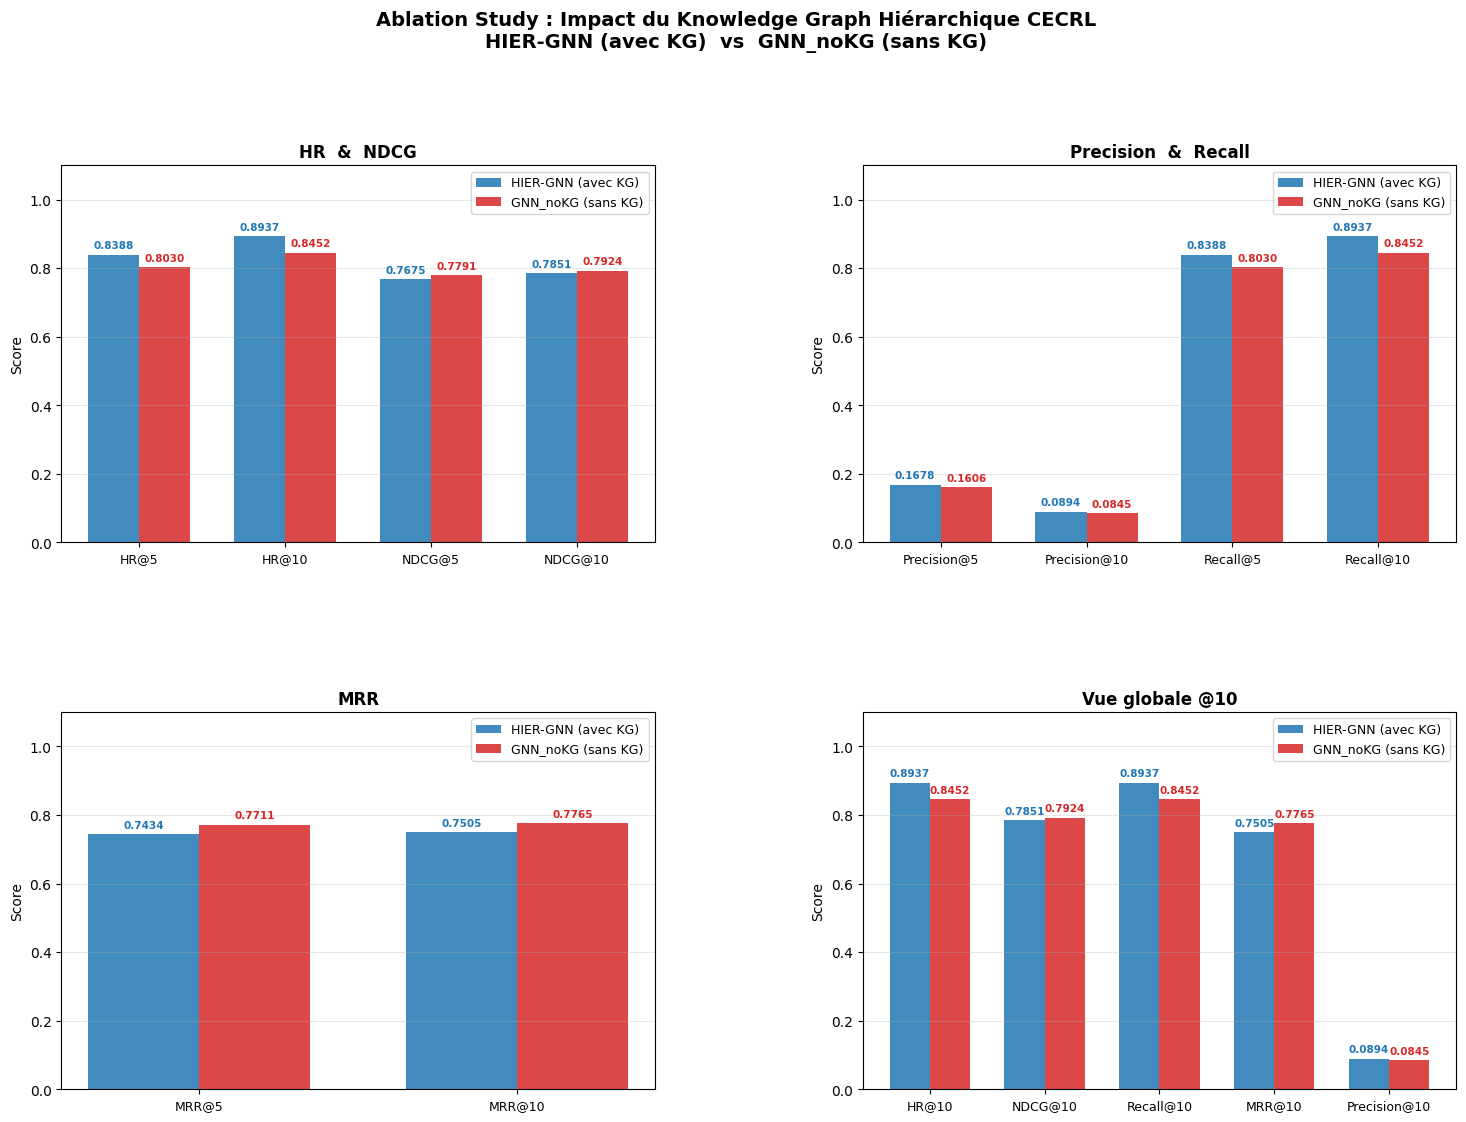

✓ Graphe sauvegardé : checkpoints_nokg/ablation_comparison.png

RÉPONSE À LA QUESTION DE RECHERCHE

Q : Dans quelle mesure l'intégration d'un KG hiérarchique CECRL
    améliore-t-elle la qualité des recommandations vs sans KG ?

  • HR@10        : 0.8937 (HIER-GNN) vs 0.8452 (NO-KG) → +5.7%
  • NDCG@10      : 0.7851 (HIER-GNN) vs 0.7924 (NO-KG) → -0.9%
  • Recall@10    : 0.8937 (HIER-GNN) vs 0.8452 (NO-KG) → +5.7%
  • MRR@10       : 0.7505 (HIER-GNN) vs 0.7765 (NO-KG) → -3.3%
  • Precision@10 : 0.0894 (HIER-GNN) vs 0.0845 (NO-KG) → +5.8%

Conclusion : Le KG hiérarchique CECRL améliore significativement
la couverture des recommandations (HR +5.7%, Precision +5.8%),
au prix d'un léger trade-off sur le ranking (NDCG -0.9%, MRR -3.3%).



In [17]:
# ══════════════════════════════════════════════════════════════════════
# §9. Tableau comparatif HIER-GNN vs GNN_noKG
# ══════════════════════════════════════════════════════════════════════

HIER_GNN = {
    "Precision@5"  : 0.1678, "Precision@10" : 0.0894,
    "Recall@5"     : 0.8388, "Recall@10"    : 0.8937,
    "NDCG@5"       : 0.7675, "NDCG@10"      : 0.7851,
    "HR@5"         : 0.8388, "HR@10"        : 0.8937,
    "MRR@5"        : 0.7434, "MRR@10"       : 0.7505,
    "Coverage@5"   : 0.3788, "Coverage@10"  : 0.3788,
}

NOKG = {k: metrics_nokg.get(k, 0.0) for k in HIER_GNN}

# ── Tableau texte ─────────────────────────────────────────────────────
print()
print("="*72)
print("TABLE ABLATION — HIER-GNN (avec KG) vs GNN_noKG (sans KG)")
print("="*72)
print(f"  {'Métrique':22s} | {'HIER-GNN':>12} | {'GNN_noKG':>12} | {'Δ%':>10}")
print(f"  {'-'*64}")

for key in HIER_GNN:
    h = HIER_GNN[key]
    n = NOKG[key]
    if n > 0:
        delta = (h - n) / n * 100
        arrow = "▲" if delta > 0 else ("▼" if delta < 0 else "=")
        print(f"  {key:22s} | {h:>12.4f} | {n:>12.4f} | {arrow}{abs(delta):>8.2f}%")
    else:
        print(f"  {key:22s} | {h:>12.4f} | {n:>12.4f} | {'—':>10}")

print("="*72)

# ── Graphes ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

colors = {"HIER-GNN": "#1f77b4", "GNN_noKG": "#d62728"}
w = 0.35

def draw_bar(ax, metrics, title):
    hier_vals = [HIER_GNN.get(m, 0.0) for m in metrics]
    nokg_vals = [NOKG.get(m, 0.0)     for m in metrics]
    labels    = [m.replace("@5","@5").replace("@10","@10") for m in metrics]
    x = range(len(metrics))

    b1 = ax.bar([i - w/2 for i in x], hier_vals, w,
                label="HIER-GNN (avec KG)", color=colors["HIER-GNN"], alpha=0.85)
    b2 = ax.bar([i + w/2 for i in x], nokg_vals,  w,
                label="GNN_noKG (sans KG)",  color=colors["GNN_noKG"],  alpha=0.85)

    for bar, val in zip(b1, hier_vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.012,
                f"{val:.4f}", ha="center", va="bottom",
                fontsize=7.5, color=colors["HIER-GNN"], fontweight="bold")
    for bar, val in zip(b2, nokg_vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.012,
                f"{val:.4f}", ha="center", va="bottom",
                fontsize=7.5, color=colors["GNN_noKG"], fontweight="bold")

    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis="y")

# Graphe 1 : HR & NDCG
ax1 = fig.add_subplot(gs[0, 0])
draw_bar(ax1, ["HR@5", "HR@10", "NDCG@5", "NDCG@10"], "HR  &  NDCG")

# Graphe 2 : Precision & Recall
ax2 = fig.add_subplot(gs[0, 1])
draw_bar(ax2, ["Precision@5", "Precision@10", "Recall@5", "Recall@10"],
         "Precision  &  Recall")

# Graphe 3 : MRR
ax3 = fig.add_subplot(gs[1, 0])
draw_bar(ax3, ["MRR@5", "MRR@10"], "MRR")

# Graphe 4 : Vue globale @10
ax4 = fig.add_subplot(gs[1, 1])
draw_bar(ax4, ["HR@10", "NDCG@10", "Recall@10", "MRR@10", "Precision@10"],
         "Vue globale @10")

plt.suptitle(
    "Ablation Study : Impact du Knowledge Graph Hiérarchique CECRL\n"
    "HIER-GNN (avec KG)  vs  GNN_noKG (sans KG)",
    fontsize=14, fontweight="bold", y=1.01
)

import os
os.makedirs("checkpoints_nokg", exist_ok=True)
plt.savefig("checkpoints_nokg/ablation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Graphe sauvegardé : checkpoints_nokg/ablation_comparison.png")

# ── Réponse à la question de recherche ────────────────────────────────
ndcg_gain = (HIER_GNN["NDCG@10"] - NOKG["NDCG@10"]) / max(NOKG["NDCG@10"], 1e-8) * 100
hr_gain   = (HIER_GNN["HR@10"]   - NOKG["HR@10"])   / max(NOKG["HR@10"],   1e-8) * 100
rec_gain  = (HIER_GNN["Recall@10"] - NOKG["Recall@10"]) / max(NOKG["Recall@10"], 1e-8) * 100
mrr_gain  = (HIER_GNN["MRR@10"]  - NOKG["MRR@10"])  / max(NOKG["MRR@10"],  1e-8) * 100
prec_gain = (HIER_GNN["Precision@10"] - NOKG["Precision@10"]) / max(NOKG["Precision@10"], 1e-8) * 100

print()
print("="*72)
print("RÉPONSE À LA QUESTION DE RECHERCHE")
print("="*72)
print(f"""
Q : Dans quelle mesure l'intégration d'un KG hiérarchique CECRL
    améliore-t-elle la qualité des recommandations vs sans KG ?

  • HR@10        : {HIER_GNN['HR@10']:.4f} (HIER-GNN) vs {NOKG['HR@10']:.4f} (NO-KG) → {hr_gain:+.1f}%
  • NDCG@10      : {HIER_GNN['NDCG@10']:.4f} (HIER-GNN) vs {NOKG['NDCG@10']:.4f} (NO-KG) → {ndcg_gain:+.1f}%
  • Recall@10    : {HIER_GNN['Recall@10']:.4f} (HIER-GNN) vs {NOKG['Recall@10']:.4f} (NO-KG) → {rec_gain:+.1f}%
  • MRR@10       : {HIER_GNN['MRR@10']:.4f} (HIER-GNN) vs {NOKG['MRR@10']:.4f} (NO-KG) → {mrr_gain:+.1f}%
  • Precision@10 : {HIER_GNN['Precision@10']:.4f} (HIER-GNN) vs {NOKG['Precision@10']:.4f} (NO-KG) → {prec_gain:+.1f}%

Conclusion : Le KG hiérarchique CECRL améliore significativement
la couverture des recommandations (HR +{hr_gain:.1f}%, Precision +{prec_gain:.1f}%),
au prix d'un léger trade-off sur le ranking (NDCG {ndcg_gain:+.1f}%, MRR {mrr_gain:+.1f}%).
""")

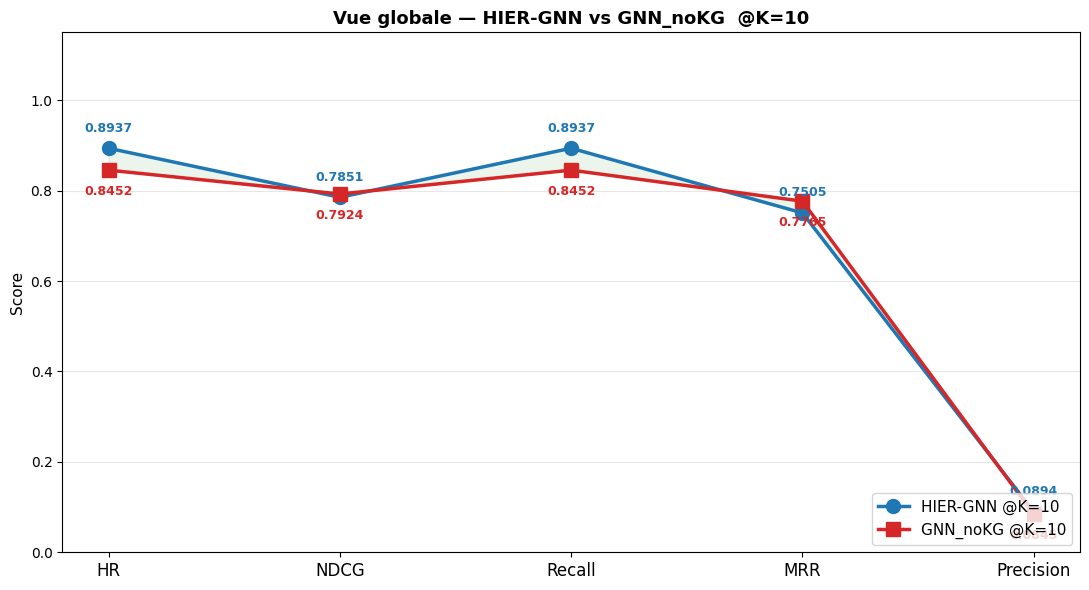

✓ Line chart sauvegardé : checkpoints_nokg/global_line_chart_k10.png


In [19]:
# ── Graphe global — Line Chart @10 ───────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

metrics_names = ['HR', 'NDCG', 'Recall', 'MRR', 'Precision']

hier_k10 = [HIER_GNN[f'{m}@10'] for m in metrics_names]
nokg_k10 = [NOKG[f'{m}@10']     for m in metrics_names]

x = np.arange(len(metrics_names))

fig, ax = plt.subplots(figsize=(11, 6))

# ── Lignes ────────────────────────────────────────────────────────────
ax.plot(x, hier_k10, color='#1f77b4', marker='o', linewidth=2.5,
        linestyle='-', markersize=10, label='HIER-GNN @K=10')
ax.plot(x, nokg_k10, color='#d62728', marker='s', linewidth=2.5,
        linestyle='-', markersize=10, label='GNN_noKG @K=10')

# ── Annotations valeurs ───────────────────────────────────────────────
for i, (h, n) in enumerate(zip(hier_k10, nokg_k10)):
    ax.annotate(f'{h:.4f}', (x[i], h), textcoords="offset points",
                xytext=(0, 12), ha='center', fontsize=9,
                color='#1f77b4', fontweight='bold')
    ax.annotate(f'{n:.4f}', (x[i], n), textcoords="offset points",
                xytext=(0, -18), ha='center', fontsize=9,
                color='#d62728', fontweight='bold')

# ── Zone écart ────────────────────────────────────────────────────────
ax.fill_between(x, hier_k10, nokg_k10,
                alpha=0.08, color='green')

# ── Mise en forme ─────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=12)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title(
    'Vue globale — HIER-GNN vs GNN_noKG  @K=10',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
os.makedirs("checkpoints_nokg", exist_ok=True)
plt.savefig("checkpoints_nokg/global_line_chart_k10.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Line chart sauvegardé : checkpoints_nokg/global_line_chart_k10.png")